# Simple Multilayer Perceptron

In [153]:
import pyarrow.parquet as pq
import numpy as np
from PIL import Image
import io

## Visualization

In [154]:
train_df.head(1) # The data is already stored as a PNG image

,image,label
0,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,5


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

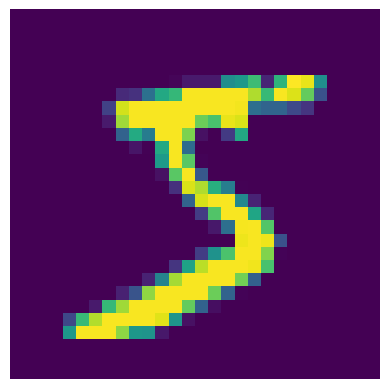

In [155]:
# To view the image (the first one)
img = Image.open(io.BytesIO(train_df["image"].head(1).iloc[0]['bytes']))

plt.imshow(img)
plt.axis('off')

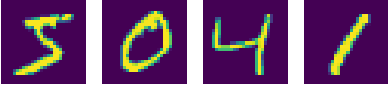

In [156]:
# Showing the first 4 images
num_images = 4
images = []
width, height = 100, 100
for byte_image_dict in train_df["image"].head(num_images):
    images.append(Image.open(io.BytesIO(byte_image_dict['bytes'])))

# The code below shows the images vertically
# for image in images:
#     plt.figure(figsize=(width, height), dpi=1) # To ensure that each plot gets it's own figure (not overwrite the previous figure)
#     plt.imshow(image)
#     plt.axis('off')
#     plt.show()

# The code below shows the images horizontally (using subplots)
fig, axes = plt.subplots(1, 4, figsize=(width, height), dpi=5)
for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i])
    ax.axis('off')
    ax.set_aspect('equal')


In [157]:
# Create a numpy array from bytes
byte_image_data = io.BytesIO(train_df["image"].head(1).iloc[0]['bytes']) # Encoded
image_data = Image.open(byte_image_data)

arr = np.array(image_data)

In [158]:
# plt.imshow(arr, cmap='grey')
# # plt.colorbar()
# plt.show()

## CODE : Neural Network

Initialize the weights to **some values**. \
For this simple simulation, I am going to use 4 layers in total (input <-> HL<sub>1</sub> <-> HL<sub>2</sub> <-> output) with input dimension being 784 (28x28 image), 16 neurons for the HLs and 10 (0-9) outputs in total.

In [159]:
# ─────────────────────────────────────────────
# 1. DATA LOADING
# ─────────────────────────────────────────────

def read_parquet_file_to_df(filename, num_data=None):
    data = pq.read_table(filename).to_pandas()
    if num_data:
        return data.head(num_data)
    return data

train_set_size = 1000
test_set_size  = 20

train_df = read_parquet_file_to_df('train.parquet')
test_df  = read_parquet_file_to_df('test.parquet')

def get_np_img_array(df):
    """Convert raw parquet image bytes → list of (28×28) uint8 numpy arrays."""
    arr = []
    for data in df["image"]:
        arr.append(np.array(Image.open(io.BytesIO(data['bytes']))))
    return arr

train_images = get_np_img_array(train_df)
test_images  = get_np_img_array(test_df)

train_labels = train_df["label"].to_numpy()
test_labels  = test_df["label"].to_numpy()

In [160]:
# ─────────────────────────────────────────────
# 2. WEIGHT & BIAS INITIALISATION
# ─────────────────────────────────────────────

def init_weight_matrix(layers):
    """
    He (Kaiming) initialisation for each weight matrix W[l]:

        W[l]  ~  N(0, sqrt(2 / fan_in))

    Shape of W[l]: (layers[l-1], layers[l])
    So the forward pass is:   Z[l] = A[l-1] @ W[l] + B[l]

    BUG FIX ①: was `np.random.rand * 0.01`  (uniform [0,1], too small, caused
               vanishing gradients immediately through sigmoid).
               Now using randn (standard normal) scaled by He factor.
    """
    wm = [None]                                     # index-0 unused (no weights into input layer)
    for i in range(len(layers) - 1):
        fan_in = layers[i]
        wm.append(np.random.randn(layers[i], layers[i+1]) * np.sqrt(2.0 / fan_in))
    return wm

def init_bias_matrix(layers):
    """
    Biases B[l] initialised to zero.
    Shape of B[l]: (1, layers[l])   — broadcasts over any batch size.
    """
    bm = [None]                                     # index-0 unused
    for i in range(1, len(layers)):
        bm.append(np.zeros((1, layers[i])))
    return bm

# Network architecture:  784 → 16 → 16 → 10
layers        = [784, 16, 16, 10]
weight_matrix = init_weight_matrix(layers)
bias_matrix   = init_bias_matrix(layers)

# Pre-activation values Z[l] stored globally so backward() can read them
zvalues = [None] * len(layers)

# Activation storage: neurons[l] holds A[l], shape (1, layers[l])
neurons = [None] + [np.zeros((1, layers[i])) for i in range(1, len(layers))]


In [161]:
# ─────────────────────────────────────────────
# 3. ACTIVATION FUNCTIONS
# ─────────────────────────────────────────────

def sigmoid(x):
    """
    σ(x) = 1 / (1 + e^{-x})
    Maps any real number to (0, 1).
    """
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_derivative(z):
    """
    σ'(z) = σ(z) · (1 − σ(z))
    Derivative of sigmoid w.r.t. its input z  (NOT w.r.t. a).
    Used in the chain rule during backprop.
    """
    s = sigmoid(z)
    return s * (1.0 - s)

# ─────────────────────────────────────────────
# 4. HELPERS
# ─────────────────────────────────────────────

def one_hot_encode(num_classes, label):
    """
    Turns an integer label into a row vector, e.g. 3 → [0,0,0,1,0,0,0,0,0,0]
    Shape: (1, num_classes)
    """
    return np.eye(num_classes)[label].reshape(1, -1)

In [162]:
# ─────────────────────────────────────────────
# 5. FORWARD PASS
# ─────────────────────────────────────────────

def forward(image):
    """
    Propagate one image through the network.

    For each layer l = 1 … L:
        Z[l] = A[l-1] @ W[l] + B[l]      (pre-activation)
        A[l] = σ(Z[l])                   (post-activation)

    Stores Z[l] in global `zvalues` (needed by backprop).
    Stores A[l] in global `neurons`.

    BUG FIX ②: previously took `neurons` as a parameter, mixing up scopes.
               Now reads/writes the global `neurons` directly for clarity.
    """
    neurons[0] = np.array(image).flatten().reshape(1, -1) / 255.0  # normalise to [0,1]

    for l in range(1, len(layers)):
        z = neurons[l-1] @ weight_matrix[l] + bias_matrix[l]       # Z[l]
        zvalues[l] = z
        neurons[l] = sigmoid(z)                                    # A[l]

# ─────────────────────────────────────────────
# 6. BACKWARD PASS  (Backpropagation)
# ─────────────────────────────────────────────

def backward(label, lr=0.1):
    """
    Compute gradients via backpropagation and update weights/biases.

    ── Output layer (L) ──────────────────────────────────────────────────────
    Loss  C = Σ (A[L] − y)²          (MSE, sum over output neurons)

    Error term:
        δ[L] = ∂C/∂Z[L]
             = ∂C/∂A[L]  ·  σ'(Z[L])
             = 2(A[L] − y)  ·  σ'(Z[L])        shape: (1, 10)

    ── Hidden layer l ────────────────────────────────────────────────────────
        δ[l] = (δ[l+1] @ W[l+1].T)  ·  σ'(Z[l])

    ── Weight & bias gradients ───────────────────────────────────────────────
        ∂C/∂W[l] = A[l-1].T  @  δ[l]           shape matches W[l]
        ∂C/∂B[l] = δ[l]                        shape matches B[l]

    ── Update rule ───────────────────────────────────────────────────────────
        W[l] ← W[l] − lr · ∂C/∂W[l]
        B[l] ← B[l] − lr · ∂C/∂B[l]

    BUG FIX ③: learning rate was 0.01 — far too small to learn in few epochs.
               Raised to 0.1.
    """
    y = one_hot_encode(10, label)                                   # target  (1, 10)

    L = len(layers) - 1                                             # index of output layer

    # ── δ for output layer ──
    delta = 2 * (neurons[L] - y) * sigmoid_derivative(zvalues[L])   # (1, 10)

    # ── Walk backwards through layers ──
    for l in range(L, 0, -1):
        dW = neurons[l-1].T @ delta                                 # (layers[l-1], layers[l])
        dB = delta                                                  # (1, layers[l])

        # Propagate delta to layer below BEFORE updating weights
        if l > 1:
            delta = (delta @ weight_matrix[l].T) * sigmoid_derivative(zvalues[l-1])

        weight_matrix[l] -= lr * dW
        bias_matrix[l]   -= lr * dB


In [163]:
# ─────────────────────────────────────────────
# 7. TRAINING LOOP
# ─────────────────────────────────────────────

def train(epochs=500, lr=0.1):
    """
    Run `epochs` full passes over the training set.

    BUG FIX ④: original code called propagate() only ONCE (1 epoch).
               The network needs many epochs to converge, especially on
               sigmoid activations with MSE loss.
    """
    for epoch in range(epochs):
        for i, image in enumerate(train_images):
            forward(image)
            backward(train_labels[i], lr=lr)

        if (epoch + 1) % 50 == 0:
            acc = accuracy(train_images, train_labels)
            print(f"Epoch {epoch+1:>4}/{epochs}  —  train accuracy: {acc:.2%}")


In [ ]:
# ─────────────────────────────────────────────
# 8. INFERENCE & EVALUATION
# ─────────────────────────────────────────────

def predict(image):
    """
    Forward-pass a single image and return the predicted digit (0–9).
        ŷ = argmax(A[L])
    """
    forward(image)
    return int(np.argmax(neurons[-1]))

def accuracy(images, labels):
    """Fraction of images classified correctly."""
    correct = sum(predict(img) == lbl for img, lbl in zip(images, labels))
    return correct / len(labels)

# ─────────────────────────────────────────────
# 9. RUN
# ─────────────────────────────────────────────

print("Training …\n")
train(epochs=500, lr=0.1)

test_acc = accuracy(test_images, test_labels)
print(f"\nFinal test accuracy: {test_acc:.2%}")

Training …

Epoch   50/500  —  train accuracy: 96.09%
Epoch  100/500  —  train accuracy: 97.01%
Epoch  150/500  —  train accuracy: 97.22%
